In [1]:
import sys
sys.path.append("..")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

nominal = pd.concat([pd.read_csv(f"../results/{c}_nominal.csv") for c in ["pid", "mpc", "rl"]], ignore_index=True)
robust = pd.read_csv("../results/robustness.csv")

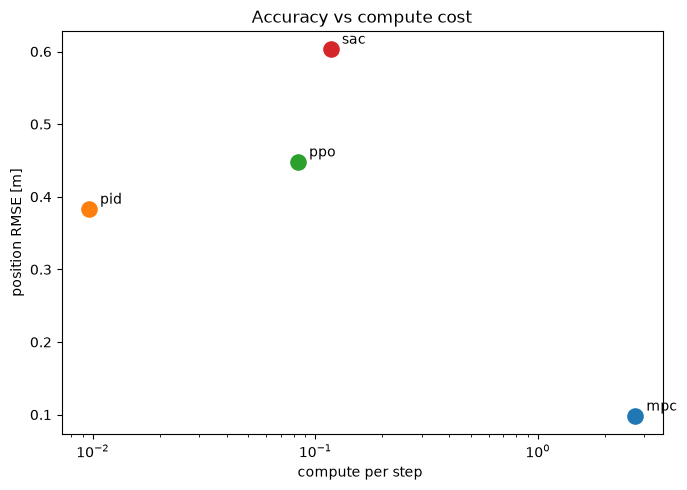

In [3]:
agg = nominal.groupby("controller").agg(pos_rmse=("pos_rmse", "mean"), compute=("compute_ms_mean", "mean")).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
for _, row in agg.iterrows():
    ax.scatter(row["compute"], row["pos_rmse"], s=120)
    ax.annotate(row["controller"], (row["compute"], row["pos_rmse"]),
                xytext=(8, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("compute per step ")
ax.set_ylabel("position RMSE [m]")
ax.set_title("Accuracy vs compute cost")
plt.tight_layout()
fig.savefig("../results/tradeoff.png", dpi=150)

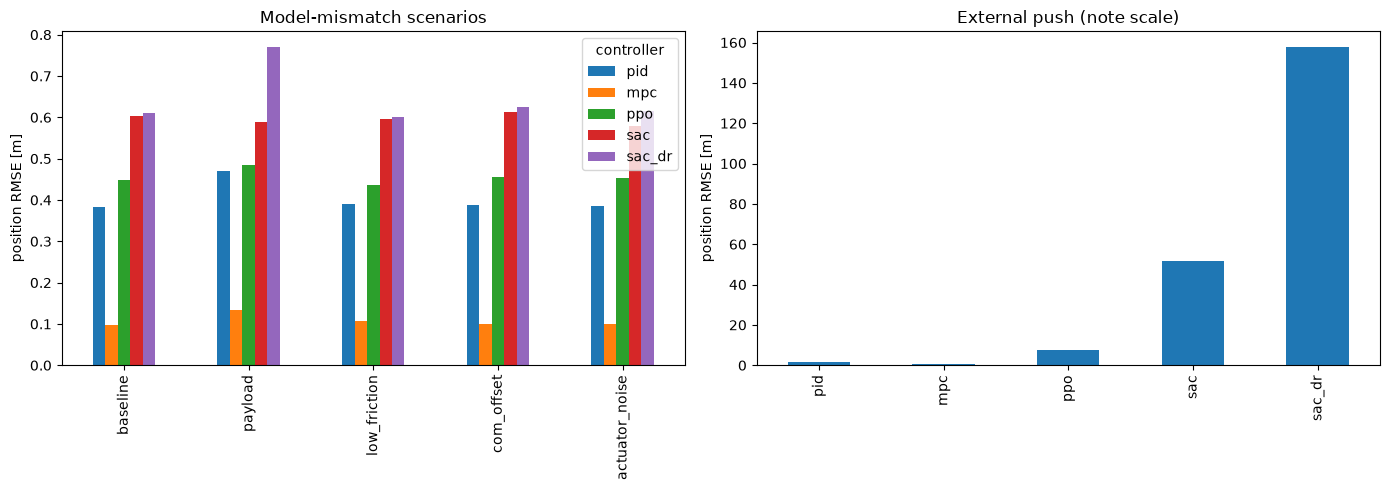

In [4]:
order = ["baseline", "payload", "low_friction", "com_offset", "actuator_noise", "external_push"]
corder = ["pid", "mpc", "ppo", "sac", "sac_dr"]
pos = robust.pivot_table(index="controller", columns="scenario", values="pos_rmse", aggfunc="mean").reindex(corder)[order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

pos[order[:-1]].T.plot(kind="bar", ax=ax1, legend=True)
ax1.set_title("Model-mismatch scenarios")
ax1.set_ylabel("position RMSE [m]")
ax1.set_xlabel("")

pos[["external_push"]].plot(kind="bar", ax=ax2, legend=False)
ax2.set_title("External push (note scale)")
ax2.set_ylabel("position RMSE [m]")
ax2.set_xlabel("")

plt.tight_layout()
fig.savefig("../results/robustness_split.png", dpi=150)

In [5]:
ratio = pos.div(pos["baseline"], axis=0).round(2)
ratio

scenario,baseline,payload,low_friction,com_offset,actuator_noise,external_push
controller,,,,,,
pid,1.0,1.23,1.02,1.01,1.01,4.25
mpc,1.0,1.37,1.11,1.01,1.03,8.98
ppo,1.0,1.08,0.97,1.02,1.01,16.79
sac,1.0,0.98,0.99,1.02,0.96,85.65
sac_dr,1.0,1.26,0.98,1.03,1.01,258.27


/Users/yashralhan/Projects/holonomic-control-benchmark/.venv/lib/python3.11/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/Users/yashralhan/Projects/holonomic-control-benchmark/.venv/lib/python3.11/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



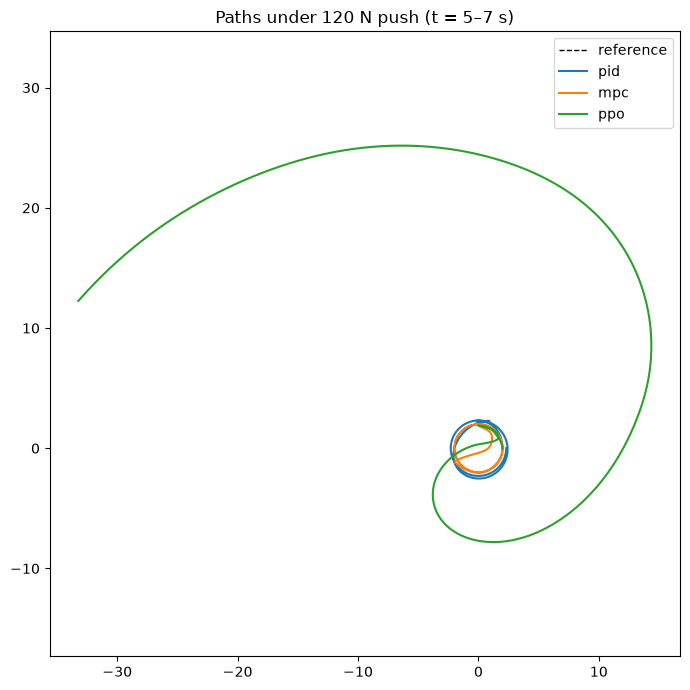

In [6]:
from controllers.pid import PidController
from controllers.mpc_01 import MpcController
from controllers.rl import RlController
from sim.disturbance import Scenario, run_tracking_disturbance
from sim.plant import act, k
from sim.trajectories import circle_ref

dt = 0.02
f_limit = 4 * act["wheel_force_max_n"]
m_limit = f_limit * k
gains = {"kp": (60.0, 60.0, 0.0), "ki": (0.0, 0.0, 0.0), "kd": (130.0, 130.0, 28.0)}
push = Scenario("external_push", ext_force=(120.0, 0.0), ext_window=(5.0, 7.0))

def build(cname):
    if cname == "pid": return PidController(gains, dt, f_limit, m_limit)
    if cname == "mpc": return MpcController(circle_ref, dt)
    if cname == "ppo": return RlController("../results/ppo_tracking", "ppo")
    if cname == "sac": return RlController("../results/sac_tracking", "sac")
    if cname == "sac_dr": return RlController("../results/sac_dr_tracking", "sac")

t = np.arange(2000) * dt
ref = circle_ref(t)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(ref[:, 0], ref[:, 1], "k--", lw=1, label="reference")
for cname in ["pid", "mpc", "ppo"]:
    res = run_tracking_disturbance(build(cname), circle_ref, 40.0, push, seed=1005)
    ax.plot(res["states"][:, 0], res["states"][:, 1], label=cname)
ax.axis("equal")
ax.legend()
ax.set_title("Paths under 120 N push (t = 5–7 s)")
plt.tight_layout()
fig.savefig("../results/push_paths.png", dpi=150)